**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


# Data Preparation

In [2]:
df = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_original = pd.read_csv("cmi_internet_copie.csv")

In [3]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [4]:
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_20,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0.0,5.0,0,3.0,51.0,0.0,16.877316,46.000,50.8,26.000,...,4,0.0,54.8,72.5,0.0,3,6.5,20.6250,2.01,448.0
1,2.0,9.0,0,1.0,58.7,0.0,14.035590,48.000,46.0,22.000,...,1,0.0,46.0,64.0,2.0,0,11.0,20.6250,2.01,433.0
2,2.0,10.0,1,0.0,71.0,0.0,16.648696,56.500,75.6,25.925,...,1,0.0,38.0,54.0,2.0,2,10.0,12.4500,2.01,453.0
3,3.0,9.0,0,0.0,71.0,2.0,18.292347,56.000,81.6,26.000,...,1,2.0,31.0,45.0,3.0,0,7.0,20.6250,2.01,577.0
4,1.0,18.0,1,2.0,65.0,1.0,17.937682,55.211,77.0,26.000,...,1,3.0,42.0,58.7,1.0,1,9.0,20.8275,1.04,448.0


# Data Partitioning

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=100, stratify=y)

In [7]:
X_train.shape

(5922, 83)

# Classification

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 

In [9]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6887312844759653
F1-score [0.8041958  0.55555556 0.36084453 0.43902439]
              precision    recall  f1-score   support

         0.0      0.792     0.817     0.804      1548
         1.0      0.551     0.560     0.556       678
         2.0      0.400     0.329     0.361       286
         3.0      0.600     0.346     0.439        26

    accuracy                          0.689      2538
   macro avg      0.586     0.513     0.540      2538
weighted avg      0.681     0.689     0.684      2538



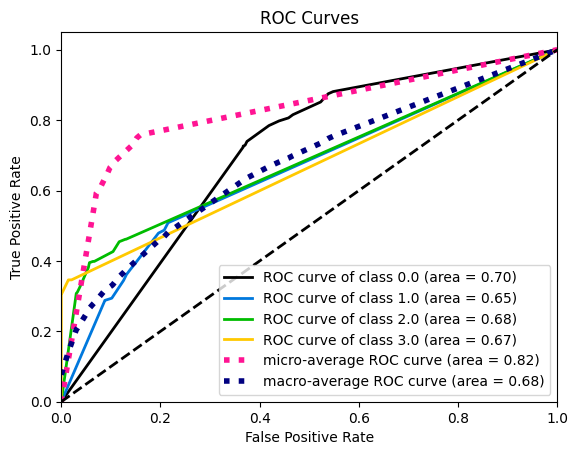

In [52]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

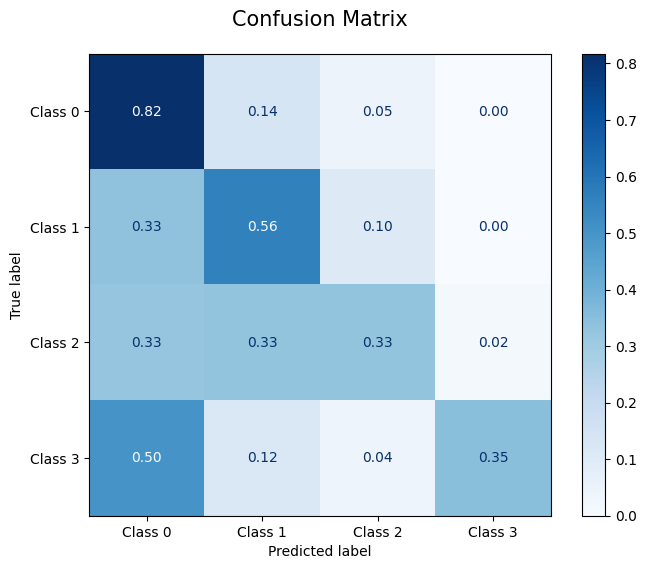

In [10]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Selection

## Variance Threshold

In [11]:
np.histogram(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])

(array([75,  3,  0,  0,  1,  1,  0,  0,  0,  1], dtype=int64),
 array([7.45156474e-02, 6.94056020e+02, 1.38803753e+03, 2.08201903e+03,
        2.77600053e+03, 3.46998204e+03, 4.16396354e+03, 4.85794505e+03,
        5.55192655e+03, 6.24590806e+03, 6.93988956e+03]))

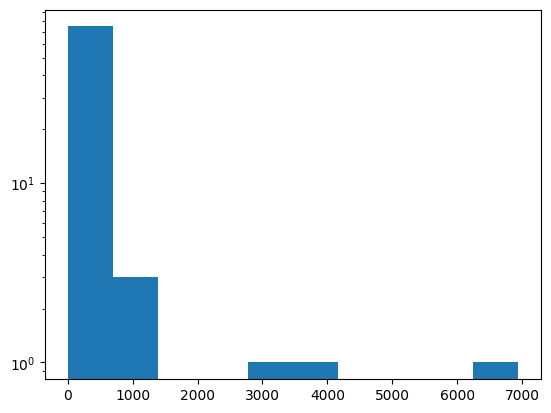

In [12]:
plt.hist(np.var(X_train, axis=0)[np.var(X_train, axis=0) < 3.14e04])
plt.yscale('log')
plt.show()

In [13]:
from sklearn.feature_selection import VarianceThreshold

In [14]:
(.8 * (1 - .8))

0.15999999999999998

In [15]:
sel = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_train_sel = sel.fit_transform(X_train)

X_train_sel.shape

(5922, 77)

In [16]:
X_train.shape

(5922, 83)

In [17]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6895193065405831
F1-score [0.80742605 0.54928518 0.35227273 0.43902439]
              precision    recall  f1-score   support

         0.0      0.787     0.829     0.807      1548
         1.0      0.561     0.538     0.549       678
         2.0      0.384     0.325     0.352       286
         3.0      0.600     0.346     0.439        26

    accuracy                          0.690      2538
   macro avg      0.583     0.510     0.537      2538
weighted avg      0.679     0.690     0.683      2538



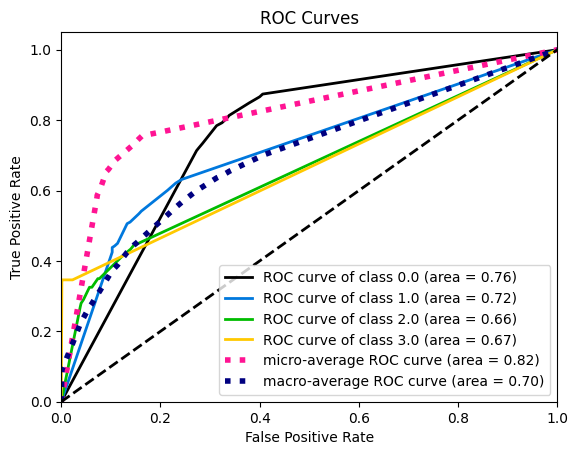

In [18]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

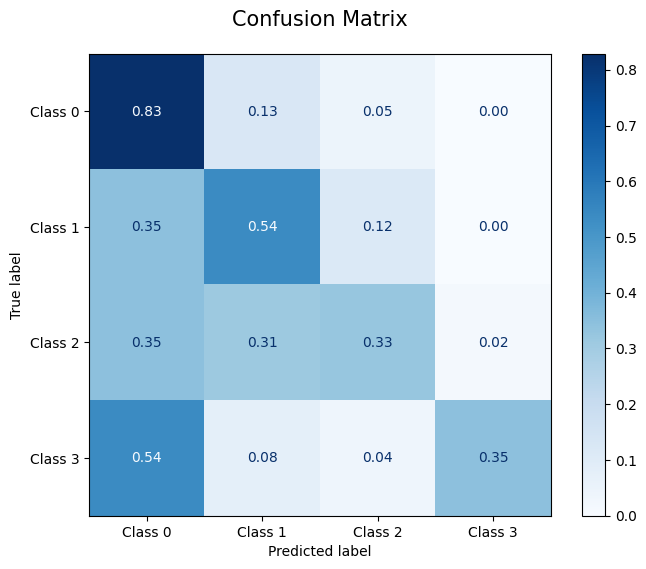

In [19]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Univariate Feature Selection

In [20]:
from sklearn.feature_selection import SelectKBest

In [21]:
sel = SelectKBest(k=40, score_func=f_classif)
X_train_sel = sel.fit_transform(X_train, y_train)

X_train_sel.shape

(5922, 40)

In [22]:
sel.scores_

array([1.39163134e+00, 1.11082402e+02, 1.86053626e+01, 9.20047336e-01,
       2.22078834e+00, 3.35738123e+00, 3.80201218e+01, 1.45744363e+02,
       1.29821166e+02, 6.61710761e+01, 6.94155427e+00, 3.34633532e+00,
       3.54837896e+01, 1.46025227e-01, 3.38134346e+00, 3.50651047e+00,
       2.47635774e+00, 1.82820580e-01, 7.38589937e+01, 3.07794153e+00,
       2.02329318e+01, 9.26350142e+00, 1.80737491e+01, 8.76308793e+00,
       5.44414014e+01, 9.97627807e+00, 2.85184770e+00, 1.54123351e+01,
       7.33669587e+00, 1.38741568e+01, 3.19676173e+00, 8.75866971e+00,
       5.00822381e+00, 4.07824818e-01, 1.36778173e+01, 5.02179397e+01,
       6.76437349e+01, 2.38657255e+01, 1.98438369e+01, 3.11006093e+01,
       6.93323303e+00, 3.80238445e+01, 6.48802161e+01, 1.65125056e+01,
       4.25944156e+01, 1.66596801e+01, 2.23773052e+01, 3.05798987e+01,
       5.17907924e+01, 4.88953545e+01, 2.50711350e+00, 2.02254852e+00,
       5.32559471e-01, 1.69404142e+00, 3.60611588e+02, 4.77449945e+02,
      

In [23]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.685973207249803
F1-score [0.8036216  0.54407295 0.3385214  0.41860465]
              precision    recall  f1-score   support

         0.0      0.778     0.831     0.804      1548
         1.0      0.561     0.528     0.544       678
         2.0      0.382     0.304     0.339       286
         3.0      0.529     0.346     0.419        26

    accuracy                          0.686      2538
   macro avg      0.562     0.502     0.526      2538
weighted avg      0.673     0.686     0.678      2538



**When k is lower the minority class doesn't have precision and recall score**

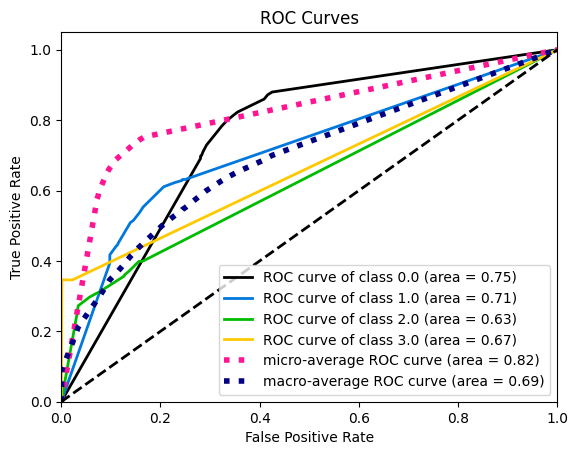

In [24]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

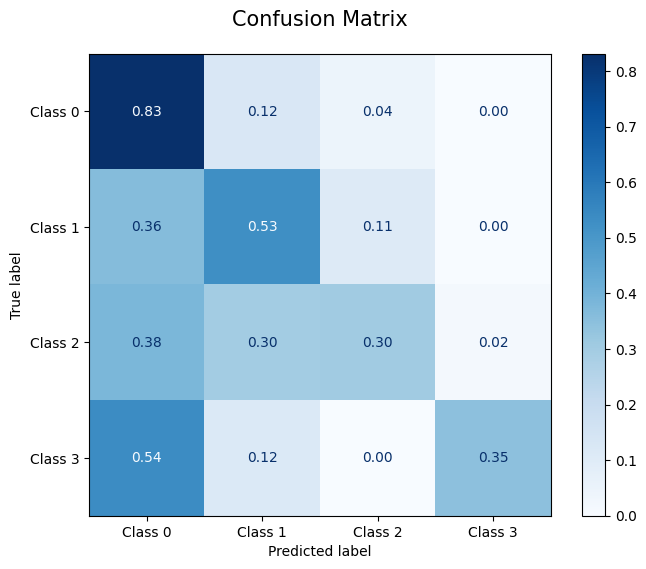

In [25]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Recursive Feature Elimination (RFE)

In [26]:
from sklearn.feature_selection import RFE

In [27]:
sel = RFE(DecisionTreeClassifier(), n_features_to_select=4)
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 4)

In [28]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.6449960598896769
F1-score [0.77962963 0.44843049 0.2826087  0.47368421]
              precision    recall  f1-score   support

         0.0      0.746     0.816     0.780      1548
         1.0      0.455     0.442     0.448       678
         2.0      0.374     0.227     0.283       286
         3.0      0.750     0.346     0.474        26

    accuracy                          0.645      2538
   macro avg      0.581     0.458     0.496      2538
weighted avg      0.626     0.645     0.632      2538



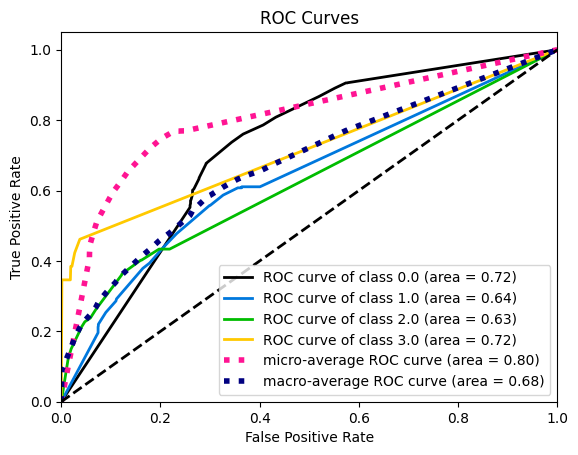

In [29]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

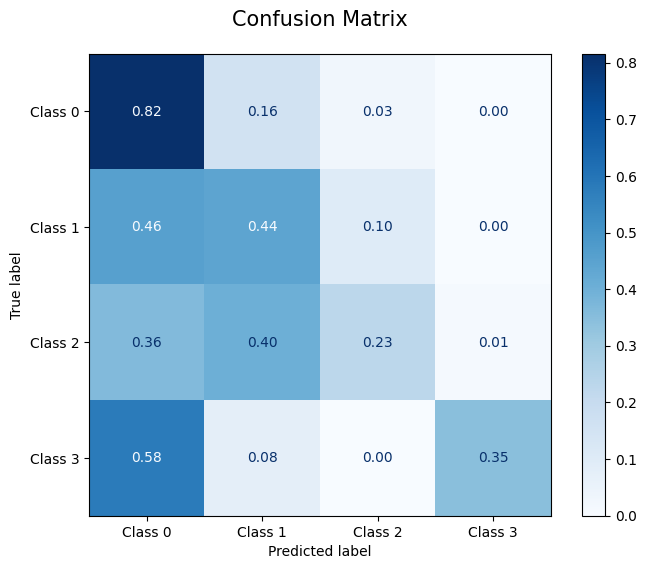

In [30]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Select Form Model
Meta-transformer for selecting features based on importance weights.

In [31]:
from sklearn.feature_selection import SelectFromModel

In [32]:
sel = SelectFromModel(DecisionTreeClassifier())
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 28)

In [33]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.677698975571316
F1-score [0.80213568 0.51224944 0.3531746  0.43902439]
              precision    recall  f1-score   support

         0.0      0.781     0.825     0.802      1548
         1.0      0.516     0.509     0.512       678
         2.0      0.408     0.311     0.353       286
         3.0      0.600     0.346     0.439        26

    accuracy                          0.678      2538
   macro avg      0.576     0.498     0.527      2538
weighted avg      0.666     0.678     0.670      2538



In [34]:
# 1. Get the boolean mask (True for kept features, False for removed)
mask = sel.get_support()

# 2. Apply this mask to your ORIGINAL column names
# Replace 'df' with the name of your original DataFrame
original_feature_names = df.columns
real_feature_names = original_feature_names[mask]

# 3. Create the cleaned-up importance table
feature_importance_df = pd.DataFrame({
    'Feature': real_feature_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                         Feature  Importance
17                PCIAT-PCIAT_05    0.201035
25                PCIAT-PCIAT_19    0.064759
24                PCIAT-PCIAT_18    0.054221
2                Physical-Height    0.040103
27               SDS-SDS_Total_T    0.039673
26             SDS-SDS_Total_Raw    0.038761
11                   BIA-BIA_FFM    0.035744
19                PCIAT-PCIAT_11    0.034612
20                PCIAT-PCIAT_13    0.034432
10                   BIA-BIA_ECW    0.033013
7           Physical-Systolic_BP    0.030698
12                  BIA-BIA_FFMI    0.030389
23                PCIAT-PCIAT_17    0.030052
16             PAQ_A-PAQ_A_Total    0.028991
5          Physical-Diastolic_BP    0.028725
14                   BIA-BIA_Fat    0.026846
15                   BIA-BIA_TBW    0.026304
9                    FGC-FGC_GSD    0.025159
13                   BIA-BIA_FMI    0.023453
8                   FGC-FGC_GSND    0.022721
18                PCIAT-PCIAT_06    0.021850
3         

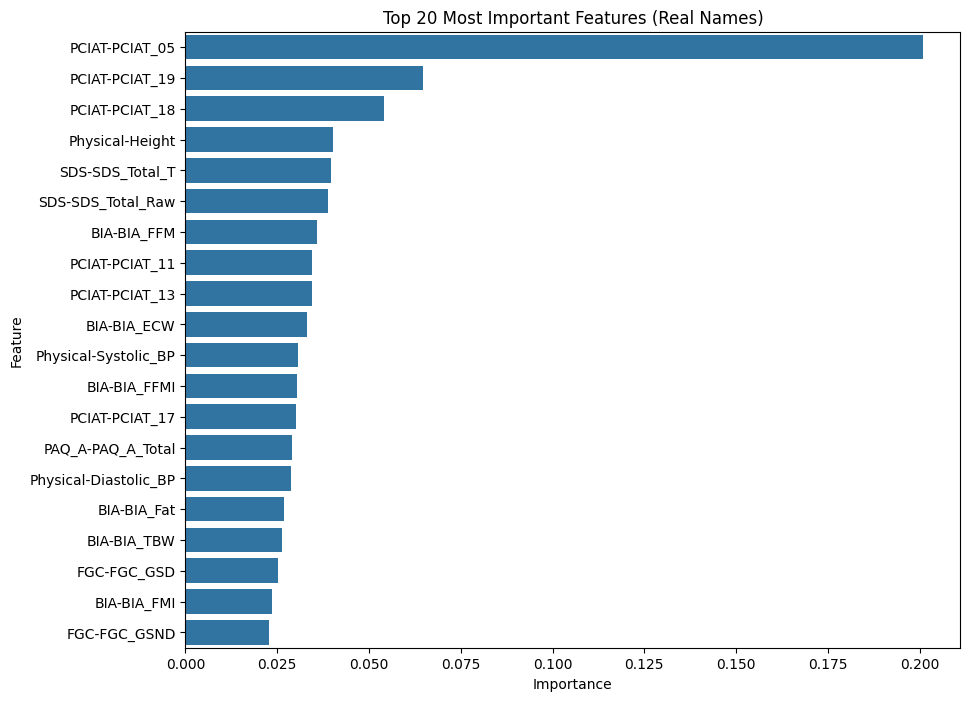

In [35]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Most Important Features (Real Names)')
plt.show()

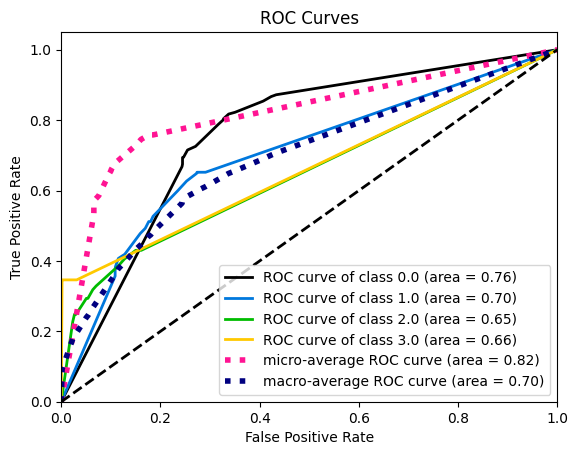

In [36]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

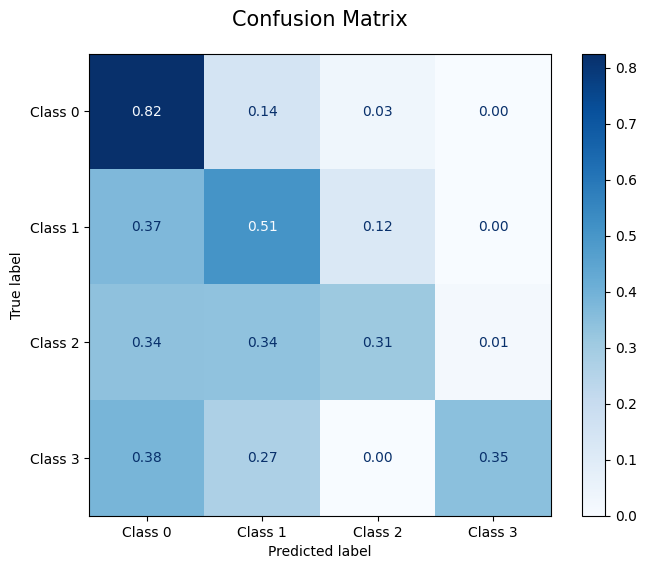

In [37]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Gradient Boosting

In [38]:
import xgboost as xgb

In [39]:
sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train, y_train)
X_train_sel.shape

(5922, 20)

In [40]:
X_test_sel = sel.transform(X_test)

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_sel, y_train)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred, digits=3))

Accuracy 0.7084318360914106
F1-score [0.8207874  0.57910448 0.37837838 0.41860465]
              precision    recall  f1-score   support

         0.0      0.801     0.842     0.821      1548
         1.0      0.586     0.572     0.579       678
         2.0      0.422     0.343     0.378       286
         3.0      0.529     0.346     0.419        26

    accuracy                          0.708      2538
   macro avg      0.585     0.526     0.549      2538
weighted avg      0.698     0.708     0.702      2538



In [41]:
# Access the fitted XGBoost model from the selector
trained_xgb = sel.estimator_

# Get importance (Gain represents the improvement in accuracy brought by a feature)
importance = trained_xgb.get_booster().get_score(importance_type='gain')

# Sort and print for better readability
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
print(sorted_importance)

[('f58', 10.679666519165039), ('f68', 6.4399919509887695), ('f56', 6.133053302764893), ('f70', 5.834327220916748), ('f72', 4.345057964324951), ('f62', 4.163084983825684), ('f60', 3.778806686401367), ('f73', 3.7345430850982666), ('f71', 3.2416458129882812), ('f67', 3.0413167476654053), ('f55', 2.6694986820220947), ('f59', 2.3122775554656982), ('f64', 2.2724111080169678), ('f57', 2.2078468799591064), ('f63', 2.1556944847106934), ('f50', 2.0999038219451904), ('f66', 2.0805842876434326), ('f61', 2.022935628890991), ('f39', 1.941826581954956), ('f27', 1.7981446981430054), ('f69', 1.5942989587783813), ('f23', 1.4975224733352661), ('f47', 1.4852274656295776), ('f45', 1.4221556186676025), ('f48', 1.3584319353103638), ('f80', 1.3489019870758057), ('f31', 1.3370791673660278), ('f22', 1.336885690689087), ('f46', 1.2878847122192383), ('f54', 1.2792340517044067), ('f29', 1.273736596107483), ('f82', 1.2733807563781738), ('f25', 1.2384073734283447), ('f7', 1.2136712074279785), ('f75', 1.1979426145553

In [42]:
original_cols = df.columns 

# Apply the mask to get only the features the selector kept
selected_names = original_cols[sel.get_support()]

# Create the table
dt_importance = pd.DataFrame({
    'Feature': selected_names,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Decision Tree Importance ---")
print(dt_importance.head(20))

--- Decision Tree Importance ---
              Feature  Importance
6      PCIAT-PCIAT_05    0.223452
1         BIA-BIA_FFM    0.191720
18     PCIAT-PCIAT_19    0.076568
17     PCIAT-PCIAT_18    0.068058
2   PAQ_A-PAQ_A_Total    0.055114
12     PCIAT-PCIAT_11    0.044385
14     PCIAT-PCIAT_14    0.036465
13     PCIAT-PCIAT_13    0.036373
5      PCIAT-PCIAT_04    0.034567
16     PCIAT-PCIAT_17    0.031971
3      PCIAT-PCIAT_02    0.030543
15     PCIAT-PCIAT_15    0.025400
7      PCIAT-PCIAT_06    0.022059
9      PCIAT-PCIAT_08    0.020900
10     PCIAT-PCIAT_09    0.019348
4      PCIAT-PCIAT_03    0.018716
11     PCIAT-PCIAT_10    0.018554
8      PCIAT-PCIAT_07    0.017692
19     PCIAT-PCIAT_20    0.015106
0    FGC-FGC_SRL_Zone    0.013008


In [43]:
importance_dict = trained_xgb.get_booster().get_score(importance_type='gain')

# 2. Map 'f#' to the column name at that index
# We use the original_cols list we defined above
real_names_dict = {}
for f_code, score in importance_dict.items():
    index = int(f_code.replace('f', ''))
    name = original_cols[index]
    real_names_dict[name] = score

# 3. Create the sorted table
xgb_importance = pd.DataFrame({
    'Feature': list(real_names_dict.keys()),
    'Gain': list(real_names_dict.values())
}).sort_values(by='Gain', ascending=False)

print("\n--- XGBoost Importance (Gain) ---")
print(xgb_importance.head(10))


--- XGBoost Importance (Gain) ---
           Feature       Gain
58  PCIAT-PCIAT_05  10.679667
68  PCIAT-PCIAT_15   6.439992
56  PCIAT-PCIAT_03   6.133053
70  PCIAT-PCIAT_17   5.834327
72  PCIAT-PCIAT_19   4.345058
62  PCIAT-PCIAT_09   4.163085
60  PCIAT-PCIAT_07   3.778807
73  PCIAT-PCIAT_20   3.734543
71  PCIAT-PCIAT_18   3.241646
67  PCIAT-PCIAT_14   3.041317


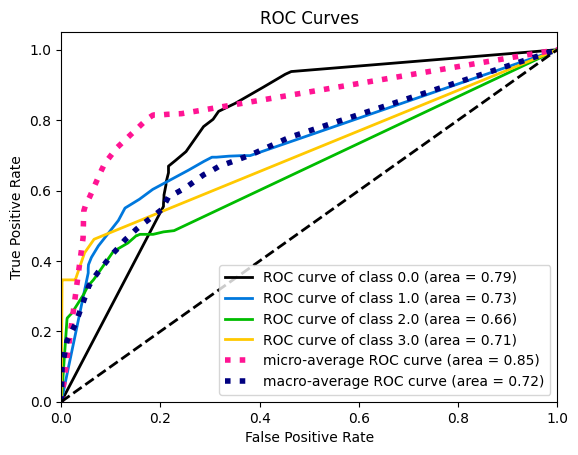

In [44]:
y_score = clf.predict_proba(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

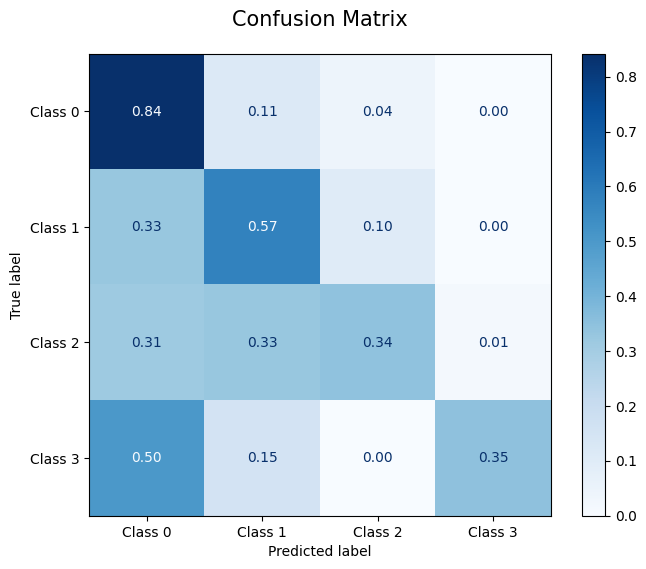

In [45]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

# Feature Projection

## Principal Component Analysis

In [46]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler   

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [49]:
X_train_pca.shape

(5922, 2)

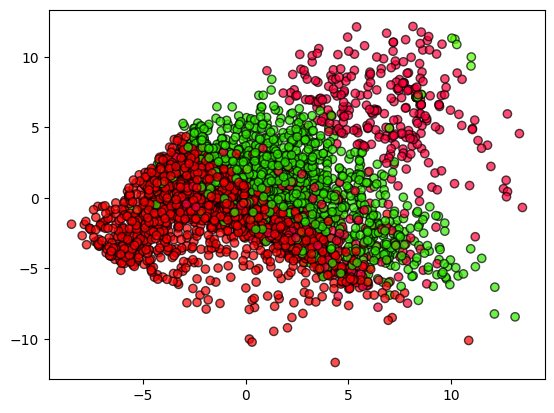

In [50]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, 
            cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [51]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.7364066193853428
F1-score [0.83546675 0.61890694 0.42650104 0.5       ]
              precision    recall  f1-score   support

         0.0       0.81      0.86      0.84      1548
         1.0       0.62      0.62      0.62       678
         2.0       0.52      0.36      0.43       286
         3.0       0.90      0.35      0.50        26

    accuracy                           0.74      2538
   macro avg       0.71      0.55      0.60      2538
weighted avg       0.73      0.74      0.73      2538



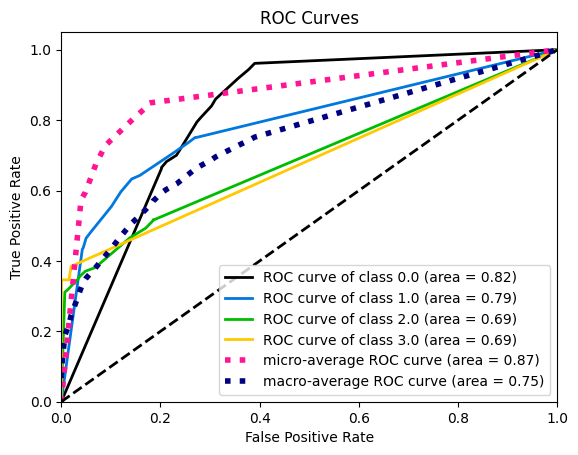

In [52]:
y_score = clf.predict_proba(X_test_pca)
plot_roc(y_test, y_score)
plt.show()

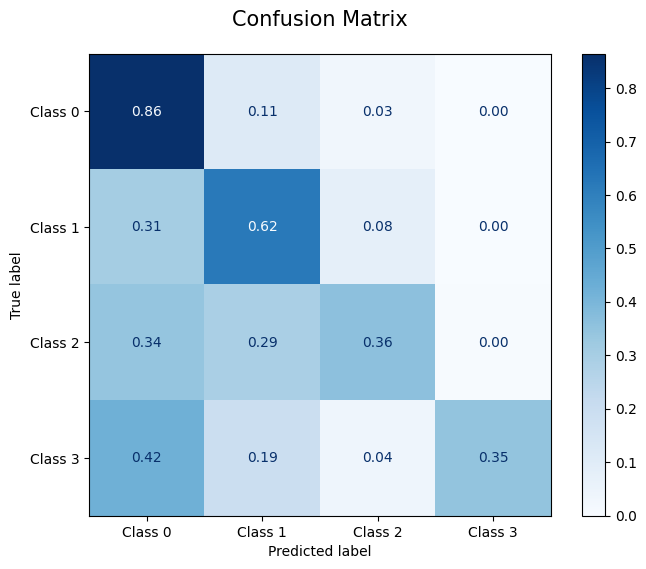

In [53]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

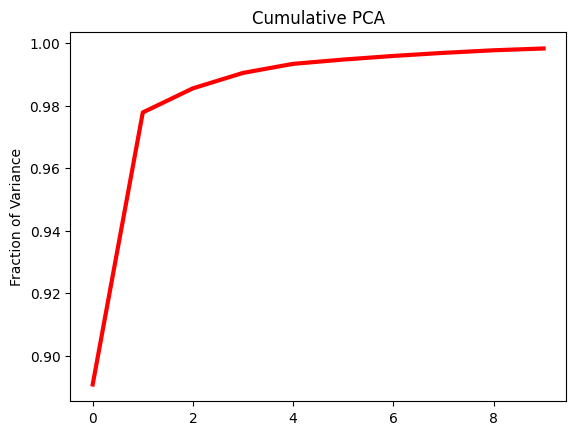

In [54]:
plt.plot(np.cumsum(PCA(n_components=10).fit(X).explained_variance_ratio_), lw=3, color='r', ms=2)
plt.title("Cumulative PCA")
plt.ylabel("Fraction of Variance")
plt.show()

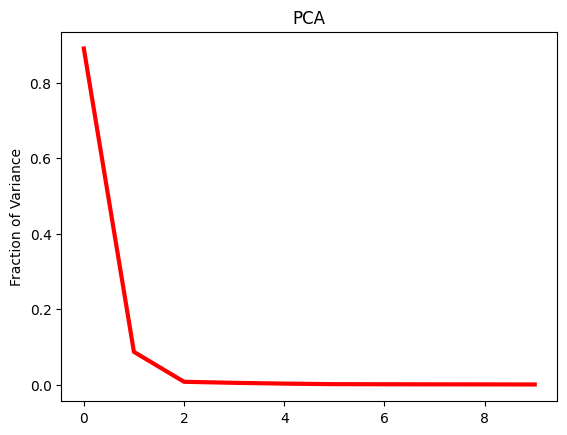

In [55]:
plt.plot(PCA(n_components=10).fit(X).explained_variance_ratio_, lw=3, color='r', ms=2)
plt.title("PCA")
plt.ylabel("Fraction of Variance")
plt.show()

# Random Subspace Projection

In [56]:
from sklearn import random_projection

In [57]:
rsp = random_projection.GaussianRandomProjection(n_components=2, random_state=None)
X_train_rsp = rsp.fit_transform(X_train_scaled)
X_test_rsp = rsp.transform(X_test_scaled)
X_train_rsp.shape

(5922, 2)

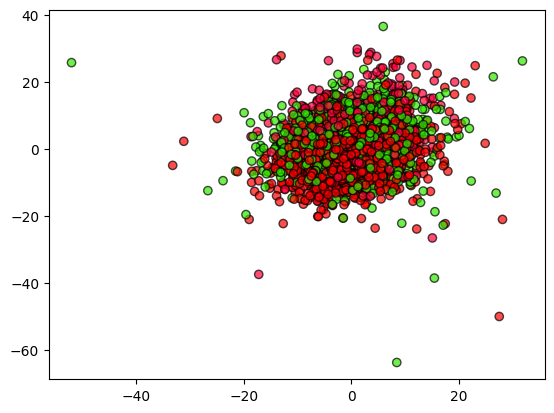

In [58]:
plt.scatter(X_train_rsp[:, 0], X_train_rsp[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [59]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_rsp, y_train)

y_pred = clf.predict(X_test_rsp)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5583136327817179
F1-score [0.70350823 0.33706189 0.20502092 0.5       ]
              precision    recall  f1-score   support

         0.0       0.68      0.73      0.70      1548
         1.0       0.34      0.33      0.34       678
         2.0       0.26      0.17      0.21       286
         3.0       0.90      0.35      0.50        26

    accuracy                           0.56      2538
   macro avg       0.54      0.40      0.44      2538
weighted avg       0.54      0.56      0.55      2538



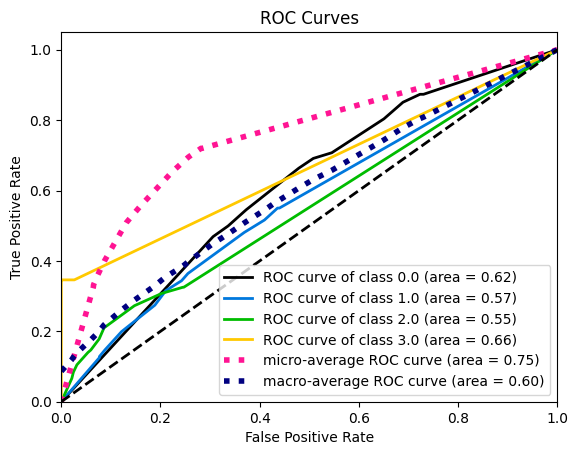

In [60]:
y_score = clf.predict_proba(X_test_rsp)
plot_roc(y_test, y_score)
plt.show()

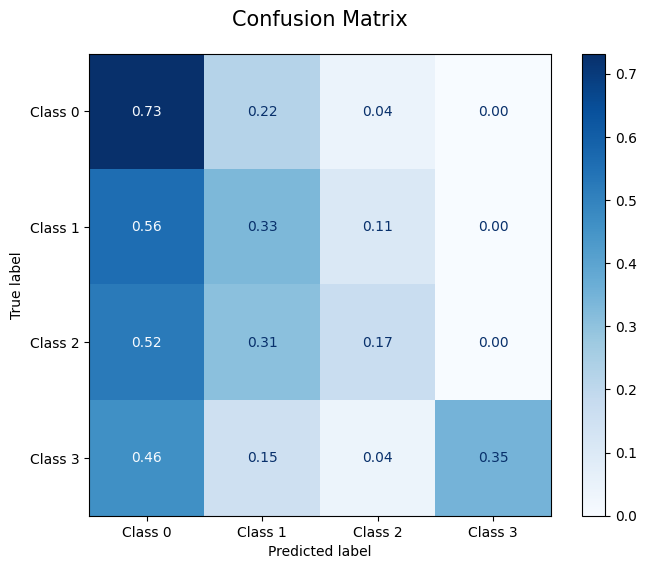

In [61]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## Multi Dimensional Scaling

In [62]:
from sklearn.manifold import MDS

In [63]:
# Specifichiamo n_init e init per evitare i FutureWarning
mds = MDS(
    n_components=2, 
    n_init=4,           # Valore attuale di default (cambierà a 1 in futuro)
    init='random',      # Valore attuale di default (cambierà a 'classical_mds')
    normalized_stress='auto',
    random_state=42     # Sempre consigliato per rendere i risultati riproducibili
)

X_train_mds = mds.fit_transform(X_train_scaled)
print(X_train_mds.shape)

(5922, 2)


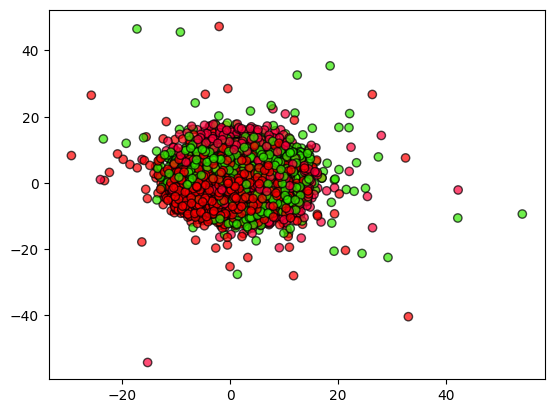

In [64]:
plt.scatter(X_train_mds[:, 0], X_train_mds[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [65]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_mds, y_train)

y_pred = clf.predict(X_train_mds)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8485309017223911
F1-score [0.90466045 0.78807518 0.66954271 0.53932584]
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90      3612
         1.0       0.81      0.77      0.79      1582
         2.0       0.79      0.58      0.67       666
         3.0       0.89      0.39      0.54        62

    accuracy                           0.85      5922
   macro avg       0.84      0.67      0.73      5922
weighted avg       0.85      0.85      0.84      5922



## IsoMap

In [66]:
from sklearn.manifold import Isomap

In [67]:
iso = Isomap(n_components=2, n_neighbors=8) # n_neighbors=5 is the default, but it is important to specify it here to avoid a warning about future changes in the default value
X_train_iso = iso.fit_transform(X_train_scaled)
X_test_iso = iso.transform(X_test_scaled)
X_train_iso.shape

(5922, 2)

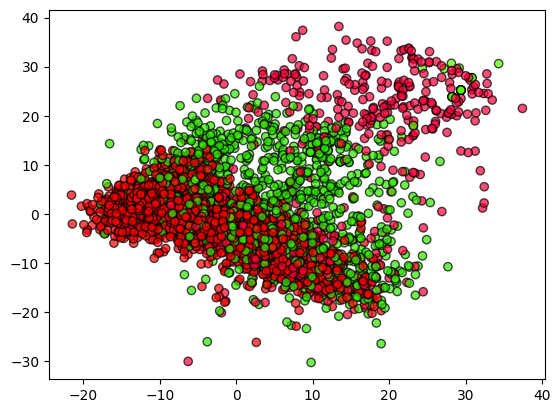

In [68]:
plt.scatter(X_train_iso[:, 0], X_train_iso[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [69]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_iso, y_train)

y_pred = clf.predict(X_test_iso)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6442080378250591
F1-score [0.76208064 0.4495766  0.39506173 0.42857143]
              precision    recall  f1-score   support

         0.0       0.73      0.80      0.76      1548
         1.0       0.47      0.43      0.45       678
         2.0       0.48      0.34      0.40       286
         3.0       0.56      0.35      0.43        26

    accuracy                           0.64      2538
   macro avg       0.56      0.48      0.51      2538
weighted avg       0.63      0.64      0.63      2538



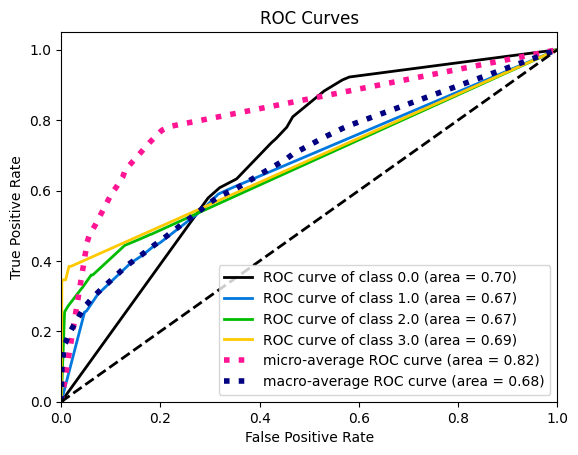

In [70]:
y_score = clf.predict_proba(X_test_iso)
plot_roc(y_test, y_score)
plt.show()

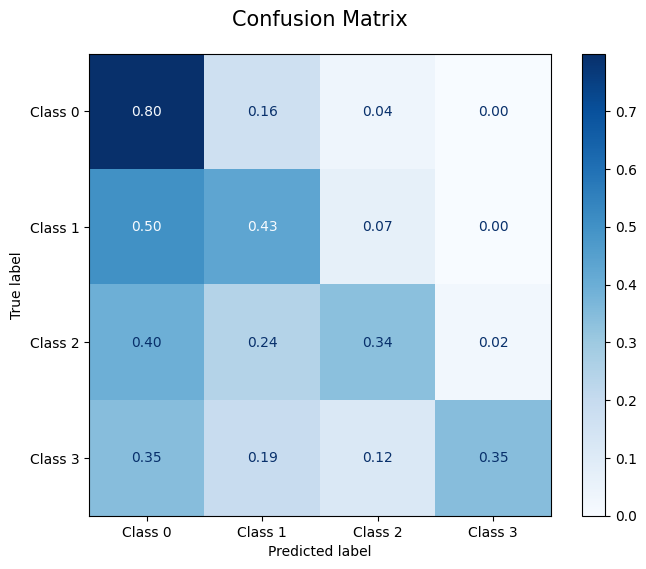

In [71]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

## t-SNE

In [72]:
from sklearn.manifold import TSNE

In [73]:
tsne = TSNE(n_components=2)
X_train_tsne = tsne.fit_transform(X_train_scaled)
X_train_tsne.shape

(5922, 2)

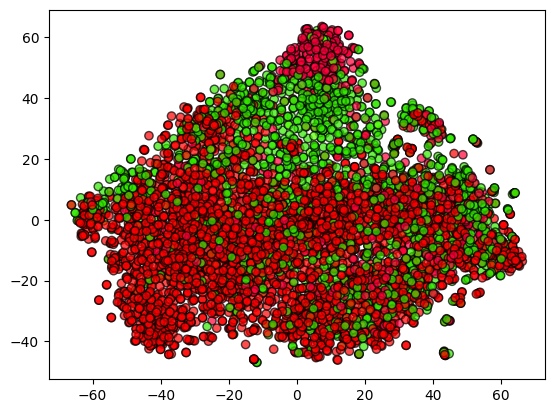

In [74]:
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
plt.show()

In [75]:
#X_test_mds = mds.transform(X_test) # no transform

clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train_tsne, y_train)

y_pred = clf.predict(X_train_tsne)

print('Accuracy %s' % accuracy_score(y_train, y_pred))
print('F1-score %s' % f1_score(y_train, y_pred, average=None))
print(classification_report(y_train, y_pred))

Accuracy 0.8716649780479567
F1-score [0.91961761 0.82502382 0.71864407 0.54545455]
              precision    recall  f1-score   support

         0.0       0.90      0.95      0.92      3612
         1.0       0.83      0.82      0.83      1582
         2.0       0.82      0.64      0.72       666
         3.0       0.92      0.39      0.55        62

    accuracy                           0.87      5922
   macro avg       0.87      0.70      0.75      5922
weighted avg       0.87      0.87      0.87      5922

